<a href="https://colab.research.google.com/github/kellygauna/PDI---Laboratorio-Ordinario/blob/main/P8_EQ_2_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRACTICA #8 :** *Aplicación de Filtros*
##### **EQUIPO #2:**
---

*   Kelly Estefanía de la Rosa Gauna - 2048165
*   Fatima Zoe Elisa Juárez Barrientos - 2004844
*   Melissa Rojas Reséndiz - 2132073

## **PARTE I. FILTROS CON MÁSCARAS ESPACIALES PERSONALIZADAS**


***Instrucciones:*** Aplicar al menos tres filtros de suavizado y filtros de detección de bordes (Sobel en x, y, Laplaciano, Kirsch).

### ***Filtros de suavizado***

Para esta primera parte se trabajó con una radiografía médica en escala de grises, la cual fue cargada utilizando OpenCV para posteriormente aplicar diferentes técnicas de suavizado.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"chest.png", cv2.IMREAD_GRAYSCALE)

Posteriormente, se aplicaron tres tipos de filtros de suavizado: filtro de media, filtro gaussiano y filtro de mediana. Cada uno fue implementado utilizando distintos tamaños de kernel (3x3, 5x5 y 11x11) con el objetivo de comparar el efecto del suavizado conforme aumenta el tamaño de la máscara.

In [ ]:
media3 = cv2.blur(img, (3,3))
media5 = cv2.blur(img, (5,5))
media11 = cv2.blur(img, (11,11))

gauss3 = cv2.GaussianBlur(img, (3,3), 0)
gauss5 = cv2.GaussianBlur(img, (5,5), 0)
gauss11 = cv2.GaussianBlur(img, (11,11), 0)

mediana3 = cv2.medianBlur(img, 3)
mediana5 = cv2.medianBlur(img, 5)
mediana11 = cv2.medianBlur(img, 11)

El filtro de media realiza un promedio de los píxeles vecinos, generando un suavizado uniforme. El filtro gaussiano aplica una ponderación basada en una distribución gaussiana, logrando un desenfoque más natural y conservando mejor las estructuras anatómicas. Por otro lado, el filtro de mediana sustituye cada píxel por la mediana de sus vecinos, siendo especialmente útil para reducir ruido impulsivo sin afectar significativamente los bordes.

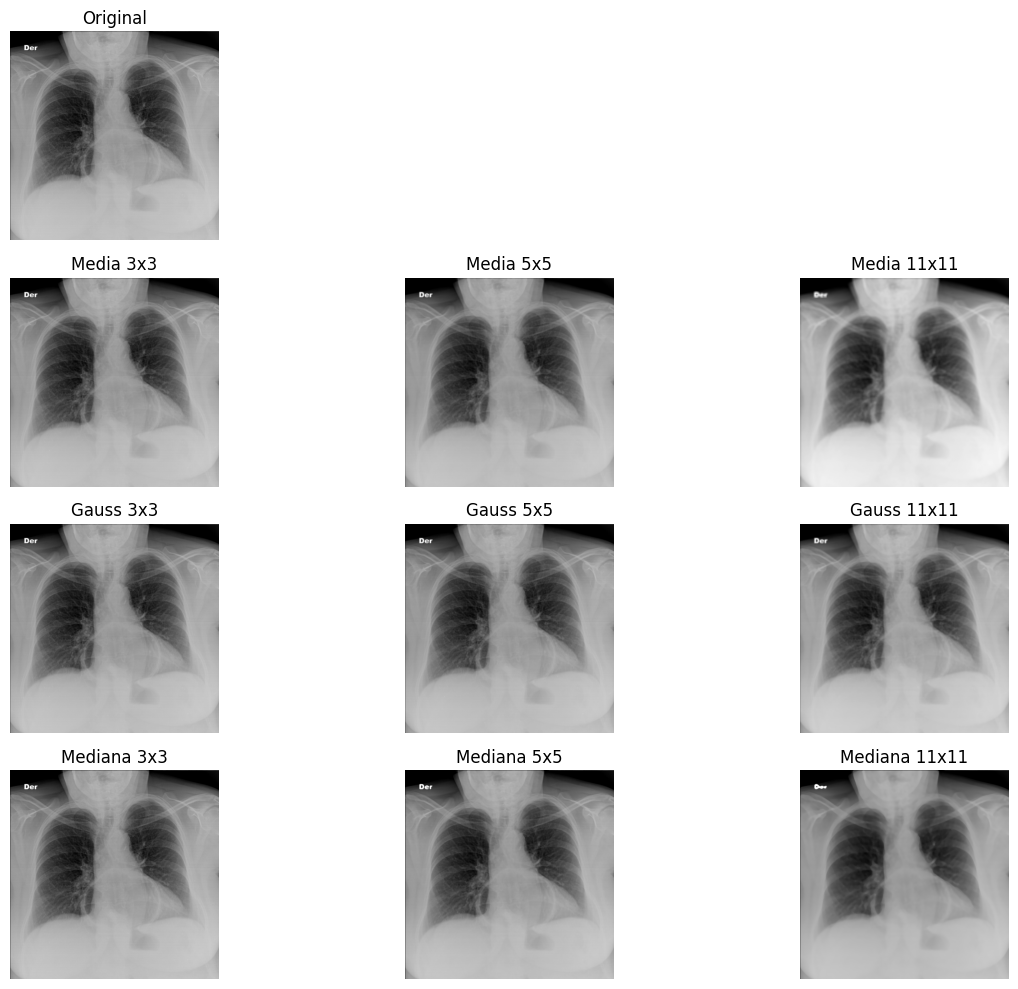

In [ ]:
plt.figure(figsize=(12,10))

plt.subplot(4,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(4,3,4)
plt.imshow(media3, cmap='gray')
plt.title("Media 3x3")
plt.axis("off")

plt.subplot(4,3,5)
plt.imshow(media5, cmap='gray')
plt.title("Media 5x5")
plt.axis("off")

plt.subplot(4,3,6)
plt.imshow(media11, cmap='gray')
plt.title("Media 11x11")
plt.axis("off")

plt.subplot(4,3,7)
plt.imshow(gauss3, cmap='gray')
plt.title("Gauss 3x3")
plt.axis("off")

plt.subplot(4,3,8)
plt.imshow(gauss5, cmap='gray')
plt.title("Gauss 5x5")
plt.axis("off")

plt.subplot(4,3,9)
plt.imshow(gauss11, cmap='gray')
plt.title("Gauss 11x11")
plt.axis("off")

plt.subplot(4,3,10)
plt.imshow(mediana3, cmap='gray')
plt.title("Mediana 3x3")
plt.axis("off")

plt.subplot(4,3,11)
plt.imshow(mediana5, cmap='gray')
plt.title("Mediana 5x5")
plt.axis("off")

plt.subplot(4,3,12)
plt.imshow(mediana11, cmap='gray')
plt.title("Mediana 11x11")
plt.axis("off")

plt.tight_layout()
plt.show()

En los resultados se observó que los kernels pequeños preservan mejor los detalles anatómicos, mientras que kernels grandes generan una pérdida considerable de nitidez. El kernel 5x5 representó un equilibrio adecuado entre reducción de ruido y conservación de estructuras importantes.

### ***Detección de bordes***

Posteriormente, se aplicaron filtros de detección de bordes para resaltar cambios bruscos de intensidad presentes en la imagen médica. Se utilizaron los operadores Sobel en dirección horizontal y vertical, el operador Laplaciano y un filtro Kirsch implementado manualmente mediante una máscara personalizada.

El operador Sobel permitió detectar bordes predominantes en direcciones específicas, mientras que el Laplaciano resaltó cambios abruptos de intensidad independientemente de la orientación. El filtro Kirsch mostró una detección más agresiva de contornos, resaltando estructuras óseas y regiones anatómicas con alta variación de intensidad.

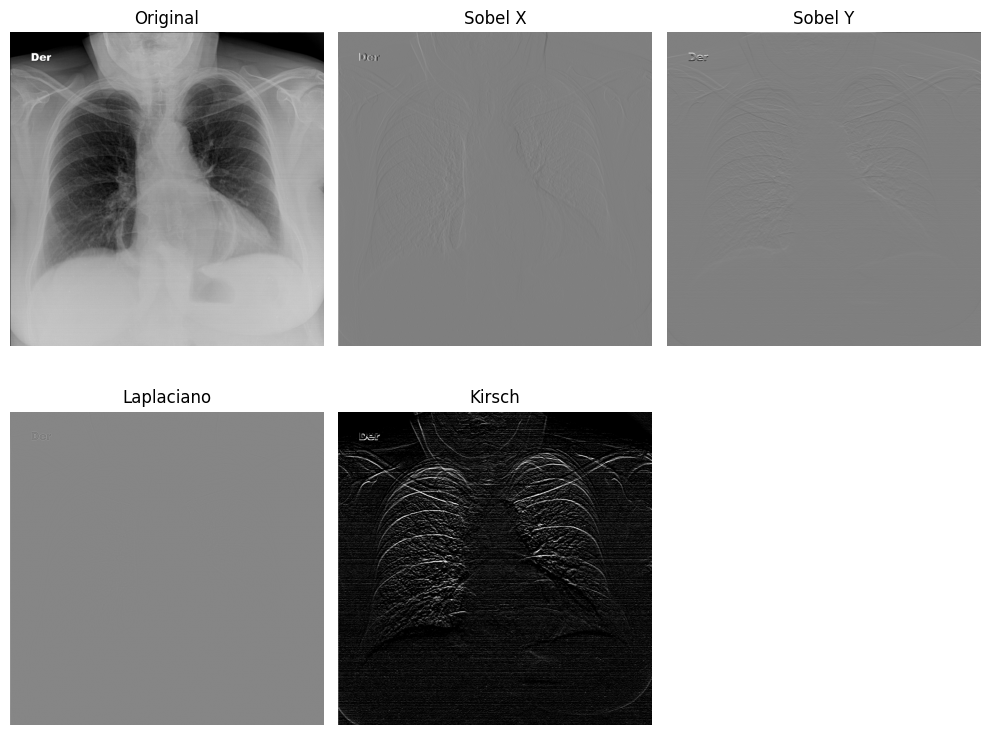

In [ ]:
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

lap = cv2.Laplacian(img, cv2.CV_64F)

kirsch = np.array([
    [5, 5, 5],
    [-3, 0, -3],
    [-3, -3, -3]
])

kirsch_img = cv2.filter2D(img, -1, kirsch)

plt.figure(figsize=(10,8))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(lap, cmap='gray')
plt.title("Laplaciano")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(kirsch_img, cmap='gray')
plt.title("Kirsch")
plt.axis("off")

plt.tight_layout()
plt.show()

### ***Máscara personalizada***

Finalmente, se diseñó una máscara personalizada de realce utilizando una configuración que incrementa la nitidez de la imagen resaltando las diferencias locales de intensidad.

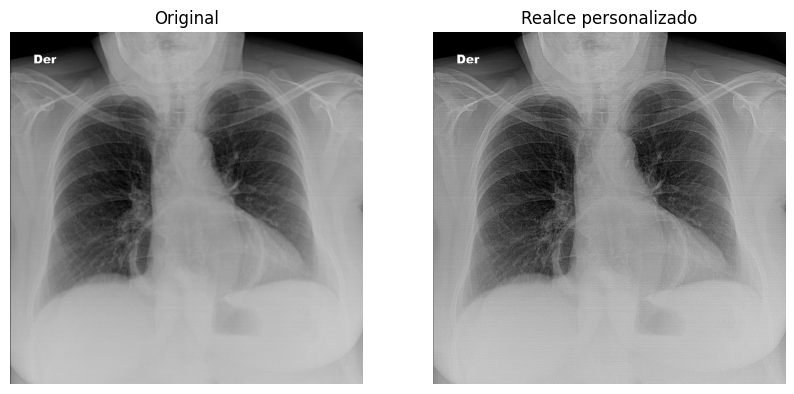

In [ ]:
kernel_custom = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

realce = cv2.filter2D(img, -1, kernel_custom)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(realce, cmap='gray')
plt.title("Realce personalizado")
plt.axis("off")

plt.show()

El resultado obtenido mostró un ligero aumento en el contraste de los bordes y una mejor definición de ciertas estructuras anatómicas, evidenciando cómo la modificación manual de máscaras permite adaptar el procesamiento a necesidades específicas de análisis médico.

## **PARTE II. FILTROS EN EL DOMINIO DE LA FRECUENCIA CON PARÁMETROS MODIFICABLES**


***Instrucciones:***  Convertir la imagen médica al dominio de la frecuencia con la Transformada de Fourier, implementar filtros pasa baja y pasa altas y comparar resultados.

### ***Filtros pasa bajas.***

Para esta segunda parte se utilizó una imagen médica diferente, la cual fue transformada al dominio de la frecuencia mediante la Transformada Discreta de Fourier. Esto permitió analizar las componentes frecuenciales de la imagen y aplicar filtros pasa bajas y pasa altas utilizando máscaras modificables.

In [ ]:
img = cv2.imread(r"cardiac-tamponade.jpg", cv2.IMREAD_GRAYSCALE)

f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

Inicialmente, se implementaron filtros pasa bajas utilizando máscaras circulares con radios de 20, 50 y 80 píxeles. Estas máscaras permiten conservar únicamente las bajas frecuencias de la imagen, asociadas principalmente a regiones suaves y cambios lentos de intensidad.

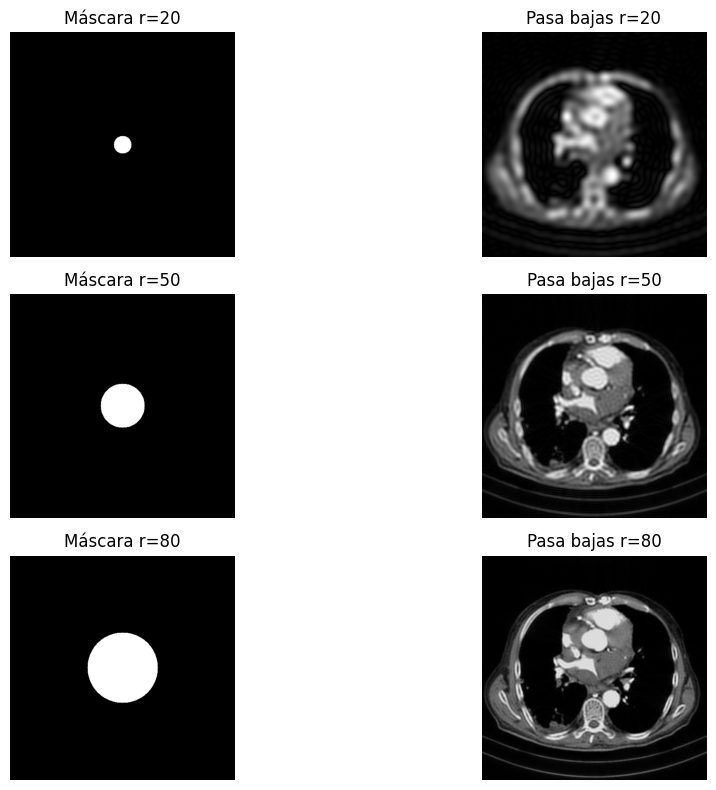

In [ ]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2

radios = [20, 50, 80]

plt.figure(figsize=(12,8))

for i, r in enumerate(radios):

    mask = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask, (ccol, crow), r, 1, -1)

    filtrada = fshift * mask

    img_back = np.fft.ifft2(np.fft.ifftshift(filtrada))
    img_back = np.abs(img_back)

    plt.subplot(3,2,2*i+1)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Máscara r={r}")
    plt.axis("off")

    plt.subplot(3,2,2*i+2)
    plt.imshow(img_back, cmap='gray')
    plt.title(f"Pasa bajas r={r}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Se observó que radios pequeños generan imágenes más borrosas debido a la eliminación de altas frecuencias, mientras que radios mayores conservan una mayor cantidad de detalles anatómicos.

### ***Filtros pasa altas.***

Posteriormente, se implementaron filtros pasa altas utilizando máscaras con configuraciones circular y en forma de cruz. Estos filtros eliminan las bajas frecuencias y conservan principalmente bordes y detalles finos de la imagen.

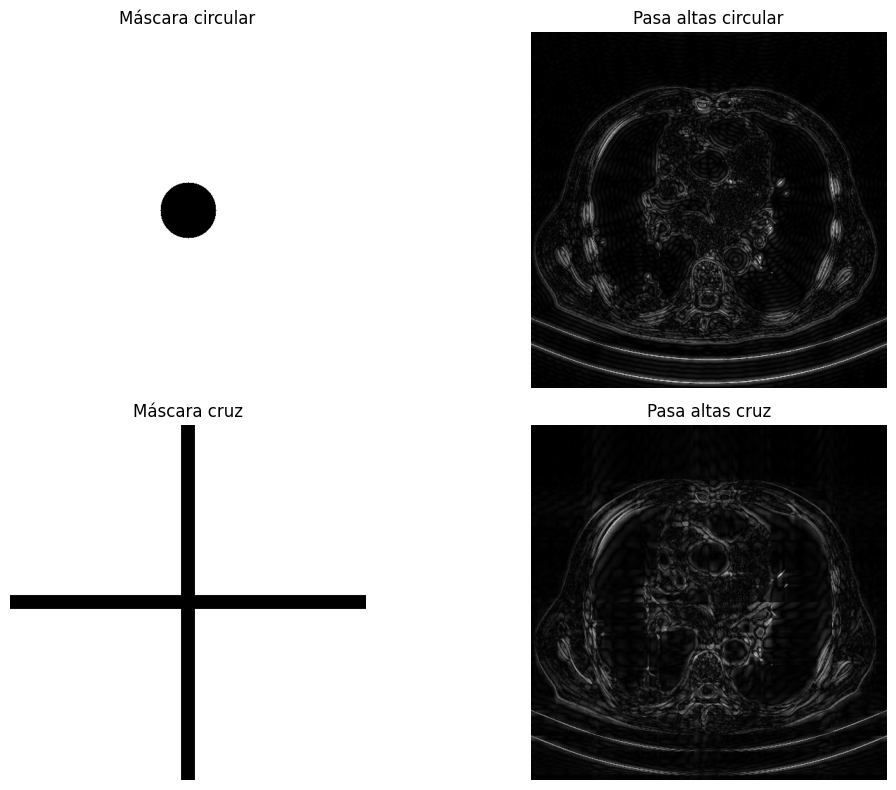

In [ ]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

rows, cols = img.shape
crow, ccol = rows//2, cols//2

# Máscara circular
mask_circle = np.ones((rows, cols), np.uint8)
cv2.circle(mask_circle, (ccol, crow), 40, 0, -1)

# Máscara cruz
mask_cross = np.ones((rows, cols), np.uint8)
mask_cross[crow-10:crow+10, :] = 0
mask_cross[:, ccol-10:ccol+10] = 0

# Aplicación
circle_filter = fshift * mask_circle
cross_filter = fshift * mask_cross

circle_back = np.abs(np.fft.ifft2(np.fft.ifftshift(circle_filter)))
cross_back = np.abs(np.fft.ifft2(np.fft.ifftshift(cross_filter)))

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(mask_circle, cmap='gray')
plt.title("Máscara circular")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(circle_back, cmap='gray')
plt.title("Pasa altas circular")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(mask_cross, cmap='gray')
plt.title("Máscara cruz")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(cross_back, cmap='gray')
plt.title("Pasa altas cruz")
plt.axis("off")

plt.tight_layout()
plt.show()

En los resultados se observó que las configuraciones pasa altas incrementan notablemente la nitidez y resaltan bordes anatómicos importantes. Sin embargo, también aumentan la presencia de ruido y pueden provocar pérdida de información suave de la imagen original.